# Regime-Based Duration Strategy

This notebook is the portfolio-ready version of the project. It organizes the full workflow into one research story:

1. Build macro and yield-curve features
2. Detect bond market regimes with a rolling HMM
3. Translate regime probabilities into target duration
4. Construct an ETF portfolio with `SHY`, `IEF`, `TLT`
5. Evaluate performance against simple benchmarks

## 0. Setup

Before running this notebook:

- fill in `.env` in the same folder
- make sure `FRED_API_KEY=...` is written there
- install packages if needed

In [1]:
# Run once if your environment is missing packages
# %pip install -r requirements.txt

In [2]:
import os
from regime_portfolio_pipeline import (
    PipelineConfig,
    regime_feature_summary,
    regime_performance_summary,
    run_pipeline,
    plot_backtest,
    plot_backtest_dashboard,
    plot_regime_feature_boxplots,
    plot_regime_overview,
    plot_regime_performance,
    plot_regime_probabilities,
    plot_strategy_weights,
)

print('FRED_API_KEY loaded:', bool(os.getenv('FRED_API_KEY')))

FRED_API_KEY loaded: True


## 1. Configuration

The base design uses a 3-regime HMM and converts posterior regime probabilities into target portfolio duration.

In [3]:
config = PipelineConfig(
    start_date='2000-01-01',
    rolling_window_months=84,
    pc1_window_days=63,
    n_regimes=3,
    covariance_type='diag',
    hmm_n_iter=500,
    hmm_n_starts=10,
    min_regime_length=3,
    probability_smoothing_alpha=0.35,
    transaction_cost_bps=4.0,
    no_trade_zone=0.02,
    regime_duration_targets={
        0: 8.0,   # Calm
        1: 14.0,  # Risk-Off
        2: 3.0,   # Inflation Shock
    },
)

config

PipelineConfig(fred_api_key='f75d683dda2053416b64caae44e1bfb2', start_date='2000-01-01', end_date=None, etf_tickers=['SHY', 'IEF', 'TLT'], etf_duration={'SHY': 2.0, 'IEF': 7.5, 'TLT': 17.5}, pc1_window_days=63, hmm_features=['PC1_Var_Z', 'VIX_Z', 'Credit_Spread_Z', 'Yield_Spread_Z', 'Inflation_YoY_Z'], rolling_window_months=84, n_regimes=3, covariance_type='diag', hmm_n_iter=500, hmm_n_starts=10, random_state=42, min_regime_length=3, winsor_lower=0.01, winsor_upper=0.99, probability_smoothing_alpha=0.35, transaction_cost_bps=4.0, no_trade_zone=0.02, regime_duration_targets={0: 8.0, 1: 14.0, 2: 3.0})

## 2. Run the pipeline

In [4]:
results = run_pipeline(config)

features = results['features']
regimes = results['regimes']
strategy_details = results['strategy_details']
return_frame = results['returns']
metrics = results['metrics']

metrics.round(4)

Model is not converging.  Current: -336.3061944263039 is not greater than -336.3061917727545. Delta is -2.6535493589108228e-06
Model is not converging.  Current: -331.1885013661502 is not greater than -331.1884756575197. Delta is -2.570863051687411e-05
Model is not converging.  Current: -346.96867882219436 is not greater than -346.9686766352419. Delta is -2.1869524857720535e-06
Model is not converging.  Current: -330.10524433403685 is not greater than -330.1052412072945. Delta is -3.1267423423742002e-06
Model is not converging.  Current: -326.8745961609679 is not greater than -326.8744874531181. Delta is -0.00010870784979033488
Model is not converging.  Current: -355.72684352247904 is not greater than -355.72683753336725. Delta is -5.989111798498925e-06
Model is not converging.  Current: -378.7118743499931 is not greater than -378.711865492059. Delta is -8.85793406268931e-06
Model is not converging.  Current: -422.38459890851556 is not greater than -422.3845916855205. Delta is -7.22299

,CAGR,Volatility,Sharpe,Sortino,Max_Drawdown,Hit_Ratio
IEF_Only,0.0258,0.0636,0.4064,0.7489,-0.2315,0.5233
Equal_Weight,0.0231,0.0687,0.3359,0.6533,-0.2641,0.5078
Regime_Duration_Strategy,0.0195,0.0670,0.2904,0.5305,-0.2348,0.4819


## 3. Regime detection

The model uses rolling PCA on Treasury yield changes and macro variables to infer hidden bond-market regimes.

In [5]:
regimes.tail(12)

,Raw_Regime,Raw_Regime_Name,Confidence,Entropy,Model_Score,Converged,Prob_State_0,Prob_State_1,Prob_State_2,Smoothed_Regime,Smoothed_Regime_Name
Date,,,,,,,,,,,
2025-04-30,2,Inflation Shock,0.998712,0.009859,-384.813455,True,0.001288,1.643356e-10,9.987120e-01,2,Inflation Shock
2025-05-31,2,Inflation Shock,0.991099,0.050918,-390.794542,True,0.008898,3.427803e-06,9.910990e-01,2,Inflation Shock
2025-06-30,2,Inflation Shock,0.999752,0.002358,-393.561746,True,0.000235,1.289917e-05,9.997520e-01,2,Inflation Shock
2025-07-31,1,Risk-Off,0.999937,0.000671,-394.290268,True,0.000063,9.999372e-01,1.455235e-07,2,Inflation Shock
2025-08-31,2,Inflation Shock,0.999994,0.000083,-390.308261,True,0.000006,9.681689e-10,9.999936e-01,2,Inflation Shock
2025-09-30,2,Inflation Shock,0.999987,0.000155,-387.346496,True,0.000013,4.441221e-11,9.999874e-01,2,Inflation Shock
2025-10-31,2,Inflation Shock,0.999985,0.000183,-386.523901,True,0.000015,1.455045e-10,9.999849e-01,2,Inflation Shock
2025-11-30,1,Risk-Off,0.999998,0.000033,-384.611134,True,0.000002,9.999976e-01,1.613312e-10,2,Inflation Shock
2025-12-31,2,Inflation Shock,0.999989,0.000141,-380.689929,True,0.000011,8.065443e-12,9.999886e-01,2,Inflation Shock


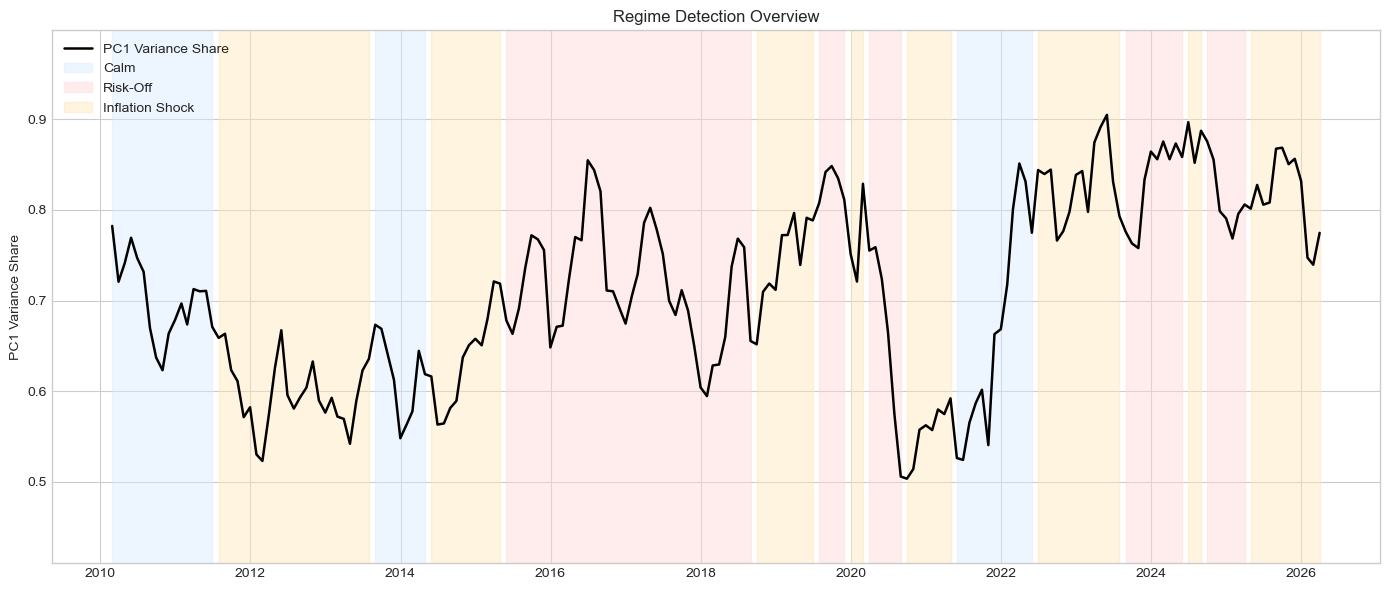

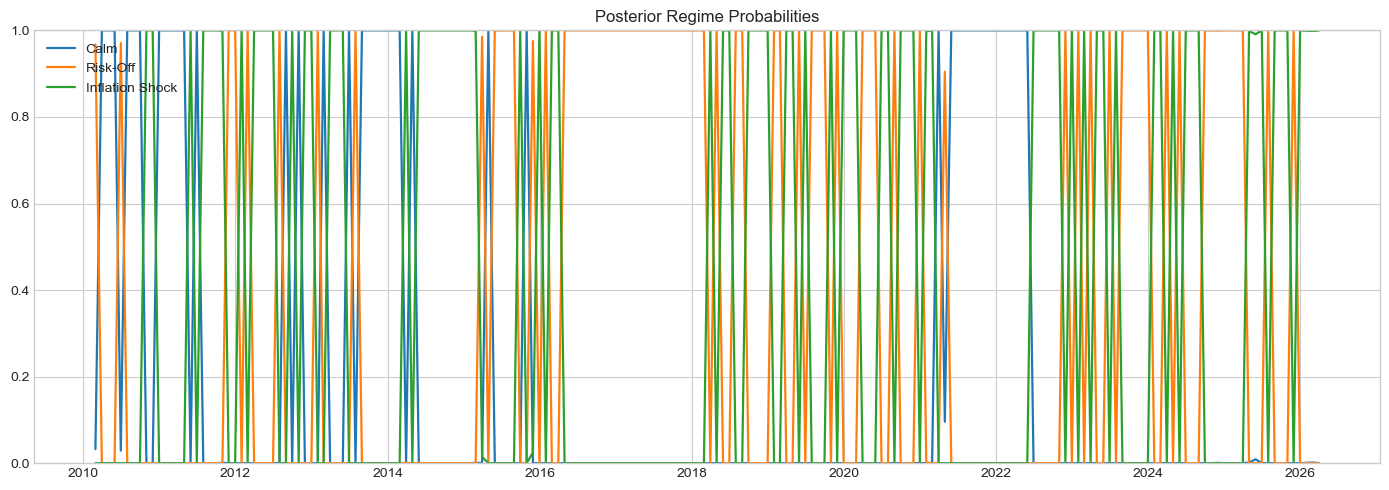

In [6]:
plot_regime_overview(features, regimes)
plot_regime_probabilities(regimes)

## 4. Regime interpretation

These tables and charts help explain what each state means in economic terms.

In [7]:
regime_feature_summary(features, regimes).round(3)

PC1_Var                         VIX  \
                                        mean median    std count    mean   
Smoothed_Regime Smoothed_Regime_Name                                       
0               Calm                   0.670  0.670  0.083    39  20.131   
1               Risk-Off               0.747  0.758  0.082    68  16.865   
2               Inflation Shock        0.699  0.679  0.116    87  19.236   

                                                          Credit_Spread  \
                                      median    std count          mean   
Smoothed_Regime Smoothed_Regime_Name                                      
0               Calm                  18.350  5.662    39         2.430   
1               Risk-Off              15.035  7.261    68         2.277   
2               Inflation Shock       17.470  6.090    87         2.366   

                                                         Yield_Spread         \
                                     median    std count         mean median   
Smoothed_Regime Smoothed_Regime_Name                                           
0               Calm                   2.54  0.428    39        1.956  2.310   
1               Risk-Off               2.20  0.593    68        0.576  0.545   
2               Inflation Shock        2.23  0.521    87        0.840  0.710   

                                                  Inflation_YoY                \
                                        std count          mean median    std   
Smoothed_Regime Smoothed_Regime_Name                                            
0               Calm                  0.831    39         3.259  2.207  2.384   
1               Risk-Off              0.608    68         1.893  2.051  1.056   
2               Inflation Shock       0.908    87         2.834  2.225  1.979   

                                            
                                     count  
Smoothed_Regime Smoothed_Regime_Name        
0               Calm                    39  
1               Risk-Off                68  
2               Inflation Shock         87

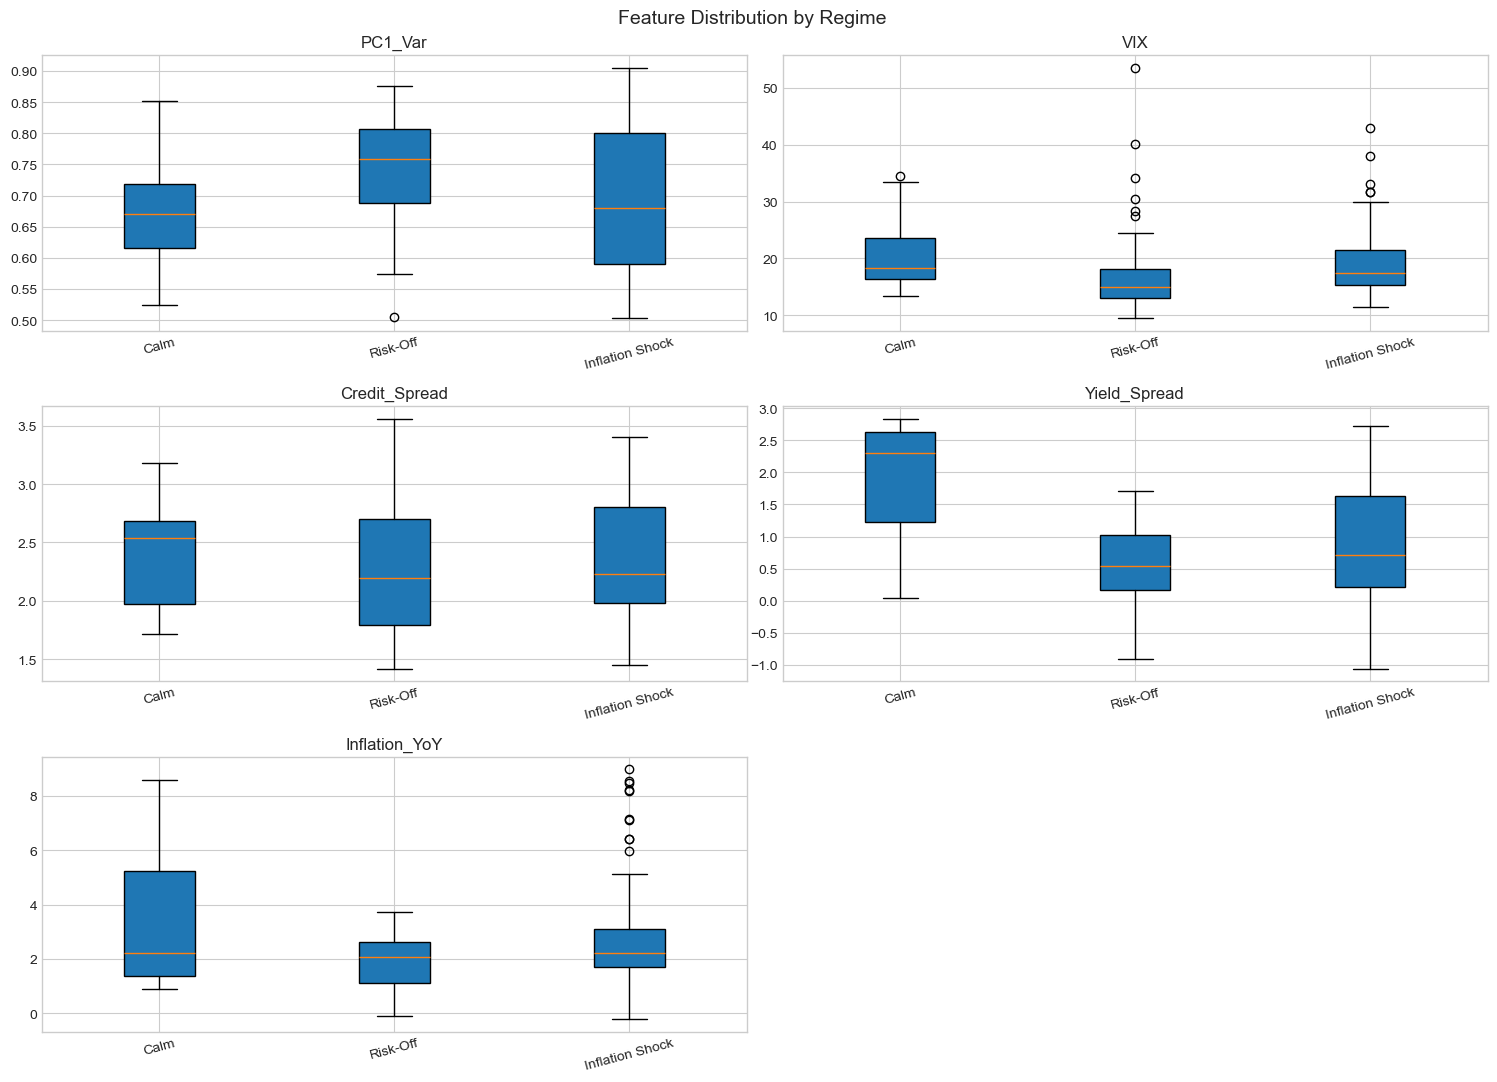

In [8]:
plot_regime_feature_boxplots(features, regimes)

## 5. Portfolio construction

Regime probabilities are converted into target duration, then mapped into ETF weights.

In [9]:
strategy_details[['Regime_Name', 'Confidence', 'Target_Duration', 'SHY', 'IEF', 'TLT']].tail(12)

,Regime_Name,Confidence,Target_Duration,SHY,IEF,TLT
Applied_Date,,,,,,
2025-04-30,Risk-Off,0.999959,13.549936,0.000000,0.395006,0.604994
2025-05-31,Inflation Shock,0.998712,9.859713,0.000000,0.764029,0.235971
2025-06-30,Inflation Shock,0.991099,7.474397,0.004655,0.995345,0.000000
2025-07-31,Inflation Shock,0.999752,5.908819,0.289306,0.710694,0.000000
2025-08-31,Inflation Shock,0.999937,8.740601,0.000000,0.875940,0.124060
2025-09-30,Inflation Shock,0.999994,6.731401,0.139745,0.860255,0.000000
2025-10-31,Inflation Shock,0.999987,5.425433,0.377194,0.622806,0.000000
2025-11-30,Inflation Shock,0.999985,4.576558,0.531535,0.468465,0.000000
2025-12-31,Inflation Shock,0.999998,7.874758,0.000000,0.962524,0.037476


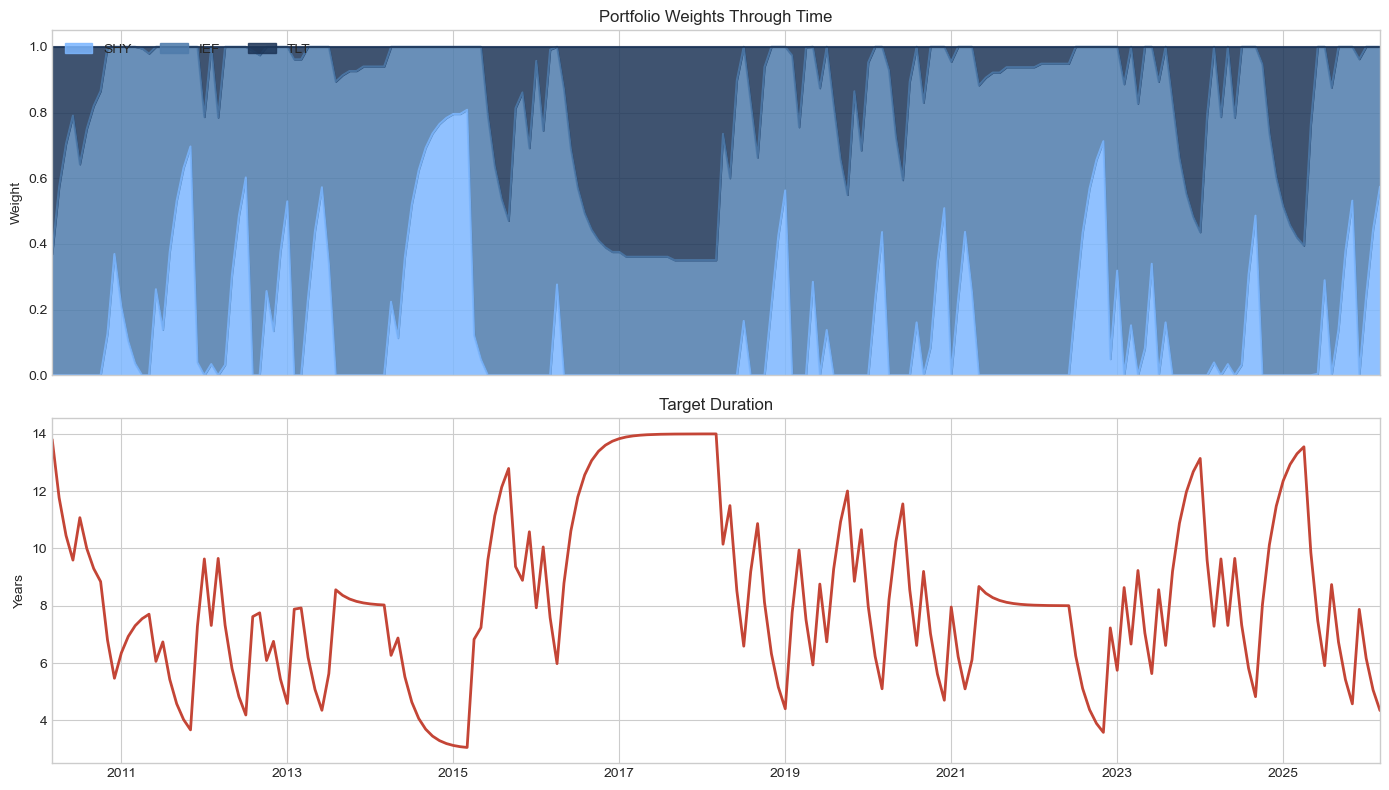

In [10]:
plot_strategy_weights(strategy_details)

## 6. Performance analysis

The strategy is compared against simple bond benchmarks and evaluated by regime as well.

In [11]:
metrics.round(4)

,CAGR,Volatility,Sharpe,Sortino,Max_Drawdown,Hit_Ratio
IEF_Only,0.0258,0.0636,0.4064,0.7489,-0.2315,0.5233
Equal_Weight,0.0231,0.0687,0.3359,0.6533,-0.2641,0.5078
Regime_Duration_Strategy,0.0195,0.0670,0.2904,0.5305,-0.2348,0.4819


In [12]:
regime_performance_summary(strategy_details).round(4)

,Avg_Monthly_Return,Volatility,Hit_Ratio,Observations
Regime_Name,,,,
Calm,0.0025,0.0202,0.4615,39
Inflation Shock,0.0025,0.0147,0.5116,86
Risk-Off,0.0005,0.0238,0.4559,68


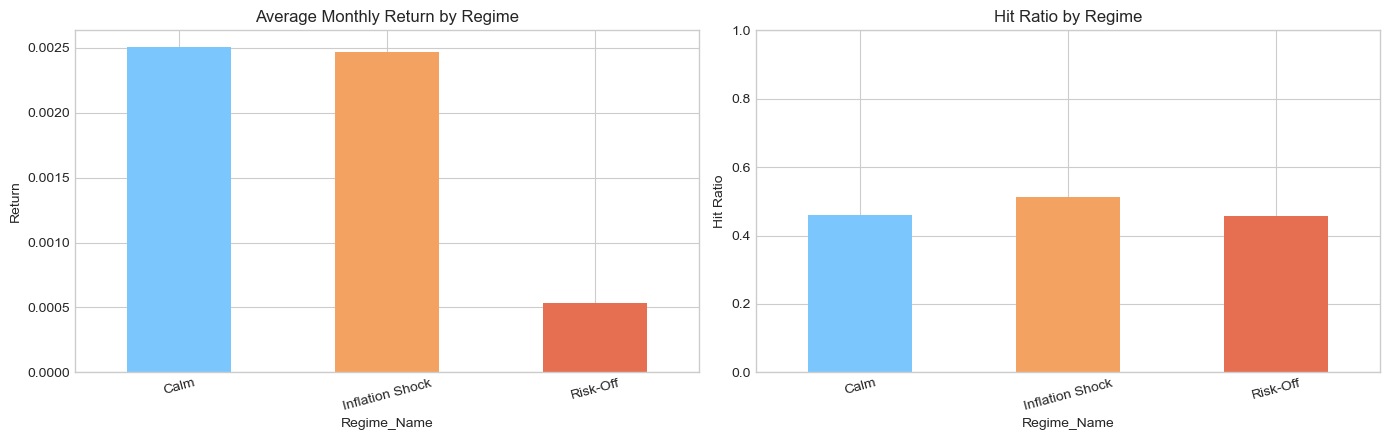

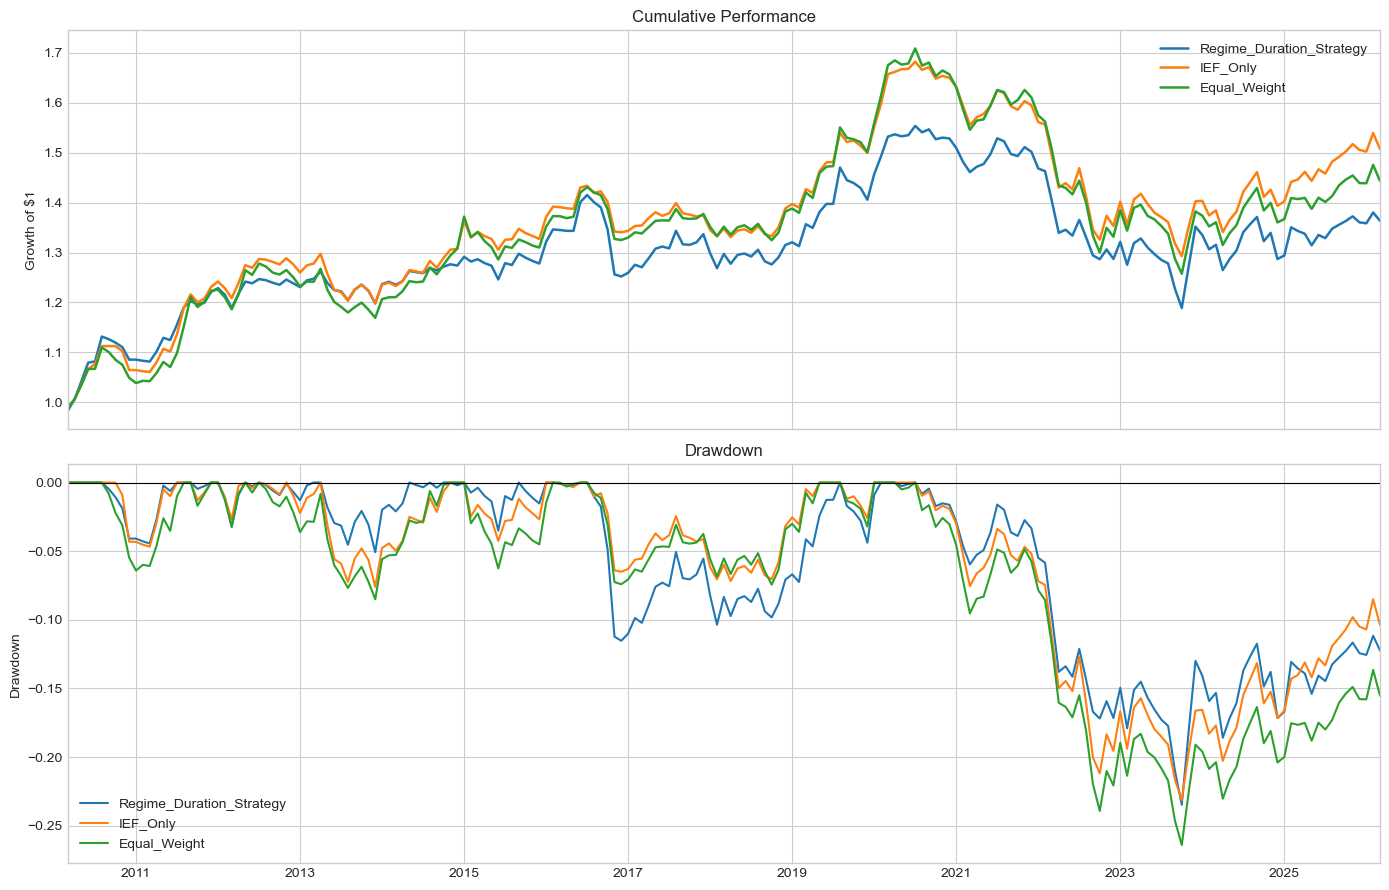

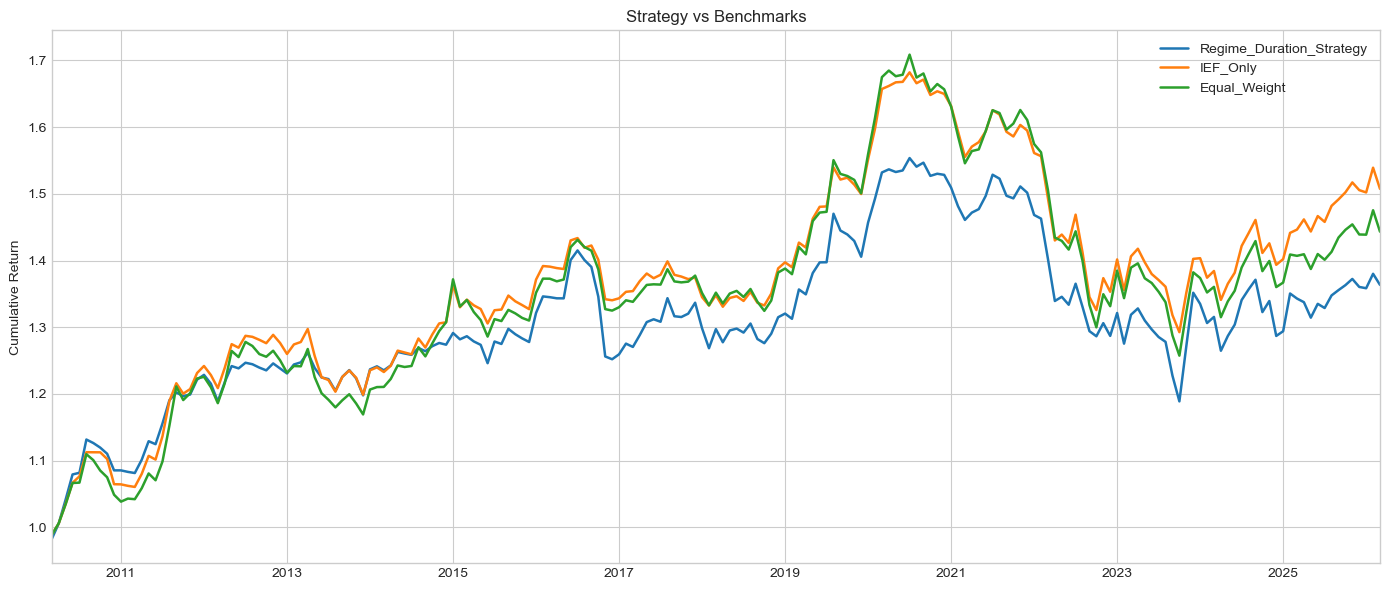

In [13]:
plot_regime_performance(strategy_details)
plot_backtest_dashboard(return_frame)
plot_backtest(return_frame)

## 7. Final snapshot

In [14]:
return_frame.tail()

,Regime_Duration_Strategy,IEF_Only,Equal_Weight
2025-11-30,0.006838,0.009881,0.005664
2025-12-31,-0.008748,-0.007612,-0.010417
2026-01-31,-0.001431,-0.002288,-0.000193
2026-02-28,0.015944,0.024700,0.025452
2026-03-31,-0.012058,-0.020643,-0.021786
